Below is: Most common political keywords, Most common keywords within 4 distinct categories, the count of the same keywords as the news analysis notebook, then visualizations of the most common political keywords at the end


In [3]:
import os
print(os.getcwd())


/Users/ailiebalke/Documents/GitHub/Media-Politics/project


In [4]:
import os
import pandas as pd

os.chdir('/Users/ailiebalke/Documents/GitHub/Media-Politics/project')

speeches_df = pd.read_csv('data/clean/pm_speeches_en.csv', index_col="date", parse_dates=True)
speeches_df.head()

,title,place,source,text
date,,,,
1951-09-07,Prime Minister Shigeru Yoshida's Speech at the...,San Francisco,"Gaimusho joyaku-kyoku hokika, Heiwa joyaku no ...",The peace treaty before the Conference contain...
1977-08-18,SPEECH BY PRIME MINISTER TAKEO FUKUDA (Fukuda ...,Manila,The Ministry of Foreign Affairs of Japan,"President Marcos, Madam Imelda Romualdez Marco..."
1988-05-04,Statement by Prime Minister Takeshita on the O...,London,Ministry of Foreign Affairs of Japan,Opening a New Era in Japanese-European Relatio...
1991-05-03,Policy Speech by Prime Minister Toshiki Kaifu ...,Singapore,"DIPLOMATIC BLUEBOOK 1991, Japan's Diplomatic A...","1. Introduction\n\nDistinguished Guests, ladie..."
1991-05-27,Address by Prime Minister Toshiki Kaifu at the...,"Kyoto, Japan","DIPLOMATIC BLUEBOOK 1991, Japan's Diplomatic A...","Ladies and gentlemen,\n\nOn behalf of the Gove..."


Finding most commmon political keywords first

In [6]:
import spacy
from collections import Counter, defaultdict

YEAR_START, YEAR_END = 2001, 2021
NOUN_POS = {"NOUN", "PROPN"}
GLUE_WORDS = {"of", "the"}

nlp = spacy.load("en_core_web_sm")

speeches_range = speeches_df[
    (speeches_df.index.year >= YEAR_START) & (speeches_df.index.year <= YEAR_END)
]

phrase_counts = Counter()
phrase_doc_ids = defaultdict(set)

for date, row in speeches_range.iterrows():
    doc = nlp(str(row["text"]))
    tokens = [token for token in doc if not token.is_space and not token.is_punct]

    i = 0
    while i < len(tokens):
        phrase_tokens = []
        j = i
        while j < len(tokens) and (
            tokens[j].pos_ in NOUN_POS
            or (tokens[j].text.lower() in GLUE_WORDS and phrase_tokens)
        ):
            phrase_tokens.append(tokens[j].text)
            j += 1

        if len(phrase_tokens) >= 2:
            phrase = " ".join(phrase_tokens).lower()
            phrase_counts[phrase] += 1
            phrase_doc_ids[phrase].add(date)

        i = j if j > i else i + 1

rows = [
    {"phrase": phrase, "total_count": count, "doc_freq": len(phrase_doc_ids[phrase])}
    for phrase, count in phrase_counts.items()
    if len(phrase_doc_ids[phrase]) >= 2
]

top_political_phrases_df = pd.DataFrame(rows).sort_values("total_count", ascending=False).head(100).reset_index(drop=True)
top_political_phrases_df


,phrase,total_count,doc_freq
0,north korea,135,26
1,rule of law,77,40
2,united states,72,48
3,number of,65,50
4,bomb survivors,59,21
...,...,...,...
95,shinzo abe prime minister of japan,14,14
96,history of,14,13
97,japan the,14,14
98,sri lanka,14,5


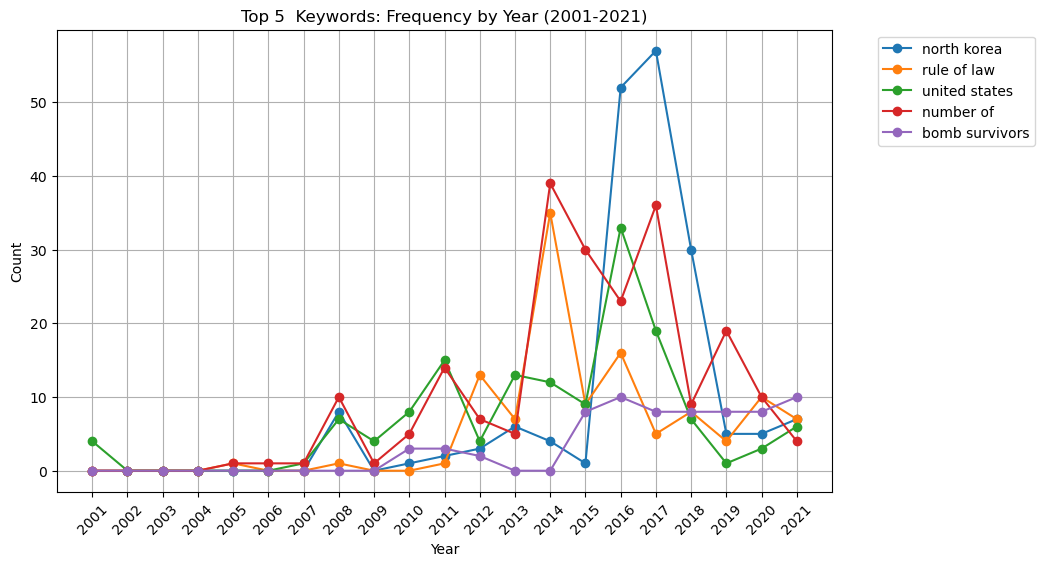

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

fig, ax = plt.subplots(figsize=(10, 6))
for phrase in top_phrases:
    ax.plot(phrase_year_df.index, phrase_year_df[phrase], marker="o", label=phrase)

ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.set_title(f"Top {TOP_N}  Keywords: Frequency by Year ({YEAR_START}-{YEAR_END})")
ax.set_xticks(range(YEAR_START, YEAR_END + 1))
ax.tick_params(axis="x", rotation=45)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True)
plt.show()



Fixed to not include things like "number of" since we don't know what thats in relation to

In [11]:
import spacy
from collections import Counter, defaultdict

YEAR_START, YEAR_END = 2001, 2021
NOUN_POS = {"NOUN", "PROPN"}
GLUE_WORDS = {"of", "the", "this", "these", "those", "our", "their", "his", "her"}
GENERIC_LEAD_WORDS = {"number", "amount", "kind", "type", "part", "lot", "rest"}

nlp = spacy.load("en_core_web_sm")

speeches_range = speeches_df[
    (speeches_df.index.year >= YEAR_START) & (speeches_df.index.year <= YEAR_END)
]

phrase_counts = Counter()
phrase_doc_ids = defaultdict(set)

for date, row in speeches_range.iterrows():
    doc = nlp(str(row["text"]))
    tokens = [token for token in doc if not token.is_space and not token.is_punct]

    i = 0
    while i < len(tokens):
        phrase_tokens = []
        j = i
        while j < len(tokens) and (
            tokens[j].pos_ in NOUN_POS
            or (tokens[j].text.lower() in GLUE_WORDS and phrase_tokens)
        ):
            phrase_tokens.append(tokens[j].text)
            j += 1

        if len(phrase_tokens) >= 2 and phrase_tokens[0].lower() not in GENERIC_LEAD_WORDS:
            phrase = " ".join(phrase_tokens).lower()
            phrase_counts[phrase] += 1
            phrase_doc_ids[phrase].add(date)

        i = j if j > i else i + 1

rows = [
    {"phrase": phrase, "total_count": count, "doc_freq": len(phrase_doc_ids[phrase])}
    for phrase, count in phrase_counts.items()
    if len(phrase_doc_ids[phrase]) >= 2
]

top_political_phrases_df = pd.DataFrame(rows).sort_values("total_count", ascending=False).head(100).reset_index(drop=True)
top_political_phrases_df


,phrase,total_count,doc_freq
0,north korea,134,25
1,rule of law,74,38
2,united states,71,47
3,bomb survivors,59,21
4,climate change,50,29
...,...,...,...
95,new york,13,11
96,behalf of the,13,13
97,year the,13,13
98,bomb diseases,13,13


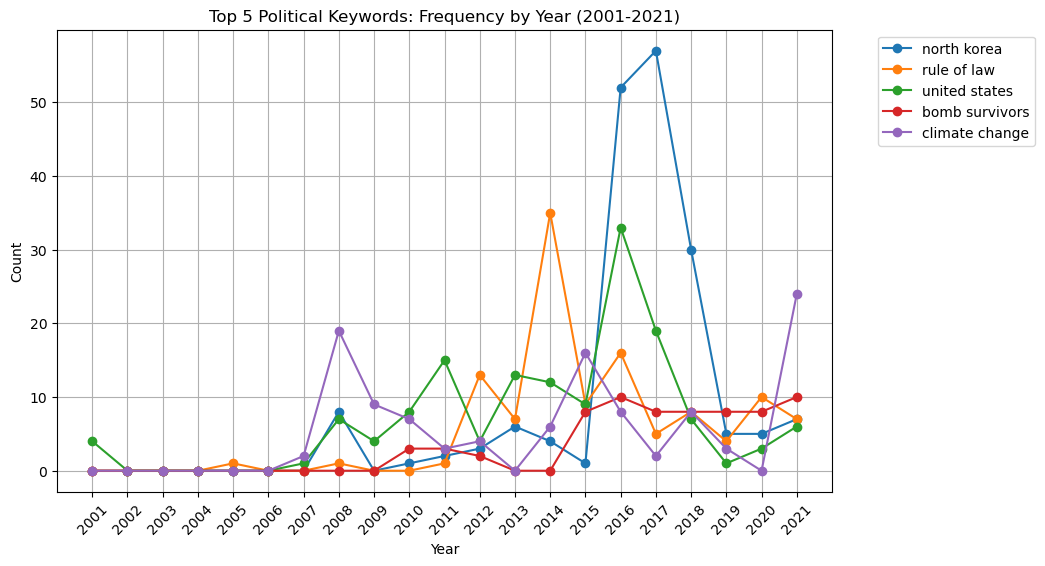

In [14]:
import re
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

TOP_N = 5
top_phrases = top_political_phrases_df["phrase"].head(TOP_N).tolist()

phrase_patterns = {
    phrase: re.compile(r"\b" + re.escape(phrase) + r"\b", re.IGNORECASE)
    for phrase in top_phrases
}

phrase_year_counts = {phrase: defaultdict(int) for phrase in top_phrases}

for date, row in speeches_range.iterrows():
    year = date.year
    text = str(row["text"])
    for phrase, pattern in phrase_patterns.items():
        count = len(pattern.findall(text))
        if count:
            phrase_year_counts[phrase][year] += count

phrase_year_df = pd.DataFrame(phrase_year_counts).reindex(range(YEAR_START, YEAR_END + 1)).fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
for phrase in top_phrases:
    ax.plot(phrase_year_df.index, phrase_year_df[phrase], marker="o", label=phrase)

ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.set_title(f"Top {TOP_N} Political Keywords: Frequency by Year ({YEAR_START}-{YEAR_END})")
ax.set_xticks(range(YEAR_START, YEAR_END + 1))
ax.tick_params(axis="x", rotation=45)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True)
plt.show()


Key change from the raw-count version: divide each phrase's yearly count by total_words_per_year (total words spoken that year, across all speeches) and scale to per-1,000-words. This corrects for years with more/longer speeches naturally having higher raw counts — a year with one short speech vs. a year with ten long ones is now comparable.

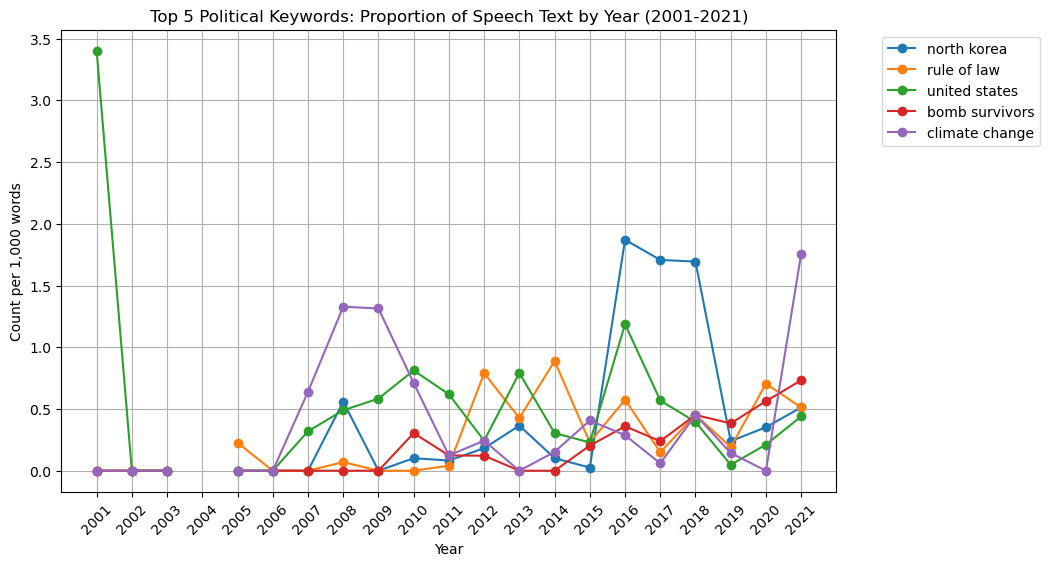

In [15]:
import re
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

TOP_N = 5
top_phrases = top_political_phrases_df["phrase"].head(TOP_N).tolist()

phrase_patterns = {
    phrase: re.compile(r"\b" + re.escape(phrase) + r"\b", re.IGNORECASE)
    for phrase in top_phrases
}
word_pattern = re.compile(r"\b\w+\b")

phrase_year_counts = {phrase: defaultdict(int) for phrase in top_phrases}
total_words_per_year = defaultdict(int)

for date, row in speeches_range.iterrows():
    year = date.year
    text = str(row["text"])
    total_words_per_year[year] += len(word_pattern.findall(text))
    for phrase, pattern in phrase_patterns.items():
        count = len(pattern.findall(text))
        if count:
            phrase_year_counts[phrase][year] += count

phrase_year_df = pd.DataFrame(phrase_year_counts).reindex(range(YEAR_START, YEAR_END + 1)).fillna(0)
total_words_df = pd.Series(total_words_per_year).reindex(range(YEAR_START, YEAR_END + 1)).fillna(0)

# proportion = occurrences per 1,000 words spoken that year, so volume of speeches doesn't skew the trend
phrase_year_proportion_df = phrase_year_df.div(total_words_df, axis=0).mul(1000)

fig, ax = plt.subplots(figsize=(10, 6))
for phrase in top_phrases:
    ax.plot(phrase_year_proportion_df.index, phrase_year_proportion_df[phrase], marker="o", label=phrase)

ax.set_xlabel("Year")
ax.set_ylabel("Count per 1,000 words")
ax.set_title(f"Top {TOP_N} Political Keywords: Proportion of Speech Text by Year ({YEAR_START}-{YEAR_END})")
ax.set_xticks(range(YEAR_START, YEAR_END + 1))
ax.tick_params(axis="x", rotation=45)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True)
plt.show()


Group by categories similar to news analysis: Defense, economy, nuclear, immigration

In [7]:
import pandas as pd
from collections import defaultdict

CATEGORY_KEYWORDS = {
    "defense": {
        "defense", "defence", "military", "self-defense", "self-defence",
        "security", "troops", "army", "navy", "armed forces", "war",
        "missile", "base", "alliance", "deterrence",
    },
    "economy": {
        "economy", "economic", "trade", "tax", "budget", "growth",
        "inflation", "employment", "wage", "industry", "investment",
        "market", "finance", "financial", "gdp", "deficit", "export",
        "import", "business", "company", "stimulus",
    },
    "nuclear": {
        "nuclear", "atomic", "reactor", "radiation", "fukushima",
        "non-proliferation", "weapons", "plutonium", "uranium",
        "power plant",
    },
    "immigration": {
        "immigration", "immigrant", "refugee", "migrant", "migration",
        "asylum", "border", "foreign worker", "visa", "naturalization",
    },
}

def categorize_phrase(phrase):
    matches = []
    for category, keywords in CATEGORY_KEYWORDS.items():
        if any(keyword in phrase for keyword in keywords):
            matches.append(category)
    return matches

category_counts = defaultdict(int)
category_phrases = defaultdict(lambda: defaultdict(int))

for phrase, count in phrase_counts.items():
    for category in categorize_phrase(phrase):
        category_counts[category] += count
        category_phrases[category][phrase] += count

category_summary_df = pd.DataFrame(
    [{"category": cat, "total_count": count} for cat, count in category_counts.items()]
).sort_values("total_count", ascending=False).reset_index(drop=True)

category_summary_df


,category,total_count
0,economy,975
1,defense,909
2,nuclear,212
3,immigration,50


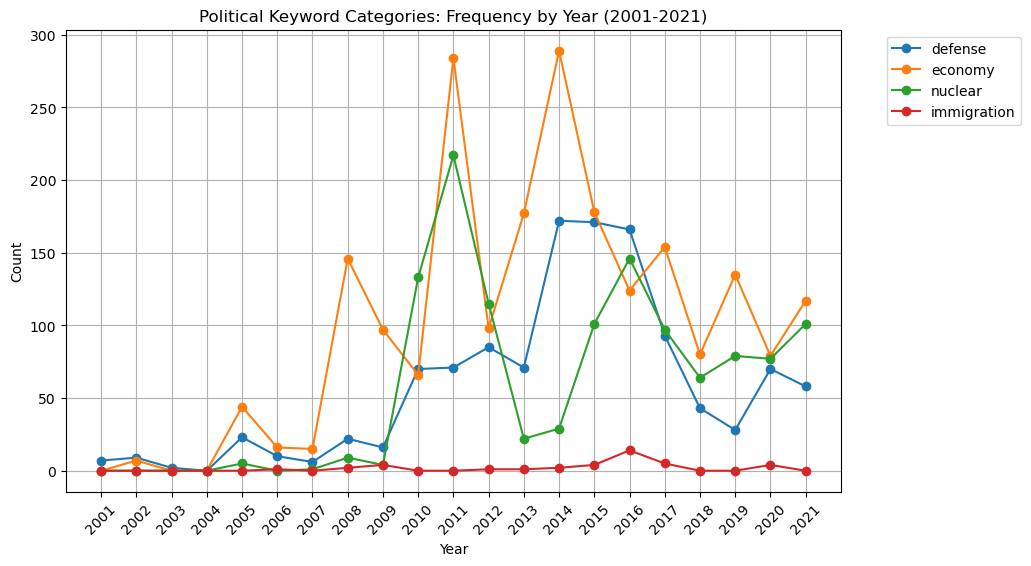

In [13]:
import re
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

category_patterns = {
    category: re.compile(
        r"\b(" + "|".join(re.escape(kw) for kw in keywords) + r")\b",
        re.IGNORECASE,
    )
    for category, keywords in CATEGORY_KEYWORDS.items()
}

category_year_counts = {category: defaultdict(int) for category in CATEGORY_KEYWORDS}

for date, row in speeches_range.iterrows():
    year = date.year
    text = str(row["text"])
    for category, pattern in category_patterns.items():
        count = len(pattern.findall(text))
        if count:
            category_year_counts[category][year] += count

category_year_df = pd.DataFrame(category_year_counts).reindex(range(YEAR_START, YEAR_END + 1)).fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
for category in CATEGORY_KEYWORDS:
    ax.plot(category_year_df.index, category_year_df[category], marker="o", label=category)

ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.set_title(f"Political Keyword Categories: Frequency by Year ({YEAR_START}-{YEAR_END})")
ax.set_xticks(range(YEAR_START, YEAR_END + 1))
ax.tick_params(axis="x", rotation=45)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True)
plt.show()


Finding top 10 phrases under the categories of: defense, nuclear, economy, immigration

In [16]:
import pandas as pd

TOP_N_PER_CATEGORY = 10

top_category_keywords_rows = []
for category in CATEGORY_KEYWORDS:
    top_phrases = sorted(category_phrases[category].items(), key=lambda x: -x[1])[:TOP_N_PER_CATEGORY]
    for rank, (phrase, count) in enumerate(top_phrases, start=1):
        top_category_keywords_rows.append({
            "category": category,
            "rank": rank,
            "phrase": phrase,
            "total_count": count,
        })

top_category_keywords_df = pd.DataFrame(top_category_keywords_rows)
top_category_keywords_df


,category,rank,phrase,total_count
0,defense,1,war japan,25
1,defense,2,security council,21
2,defense,3,security environment,20
3,defense,4,self defense forces,19
4,defense,5,missile issues,15
5,defense,6,security system,14
6,defense,7,missile launches,12
7,defense,8,reform of the security council,11
8,defense,9,japan u.s. alliance,11
9,defense,10,ravages of war,11


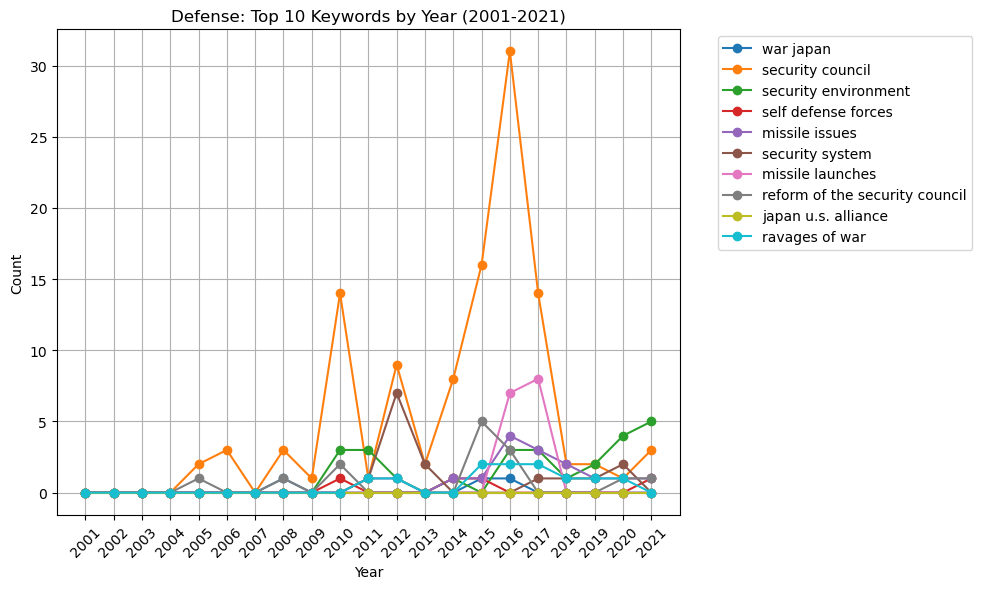

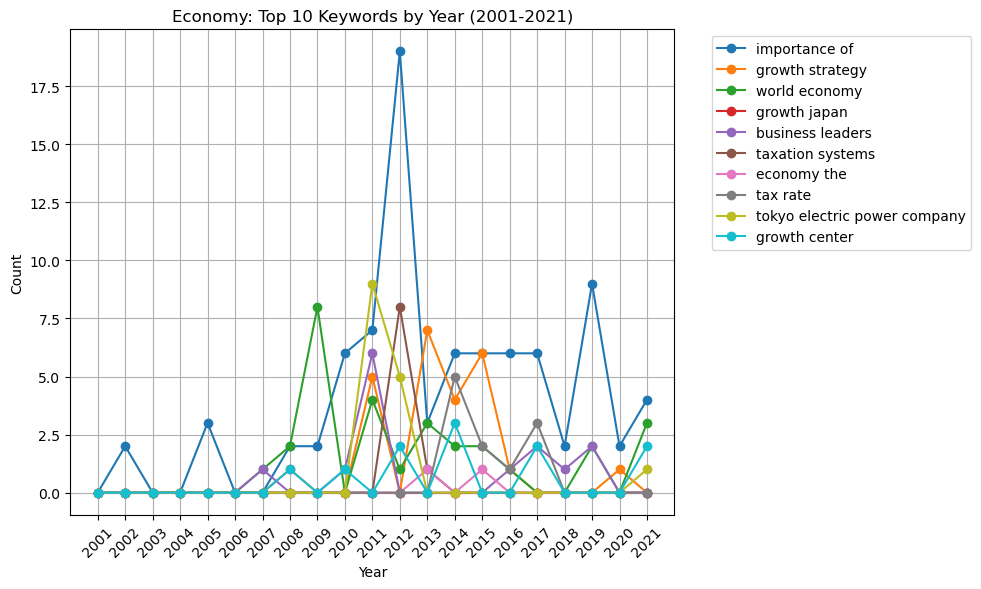

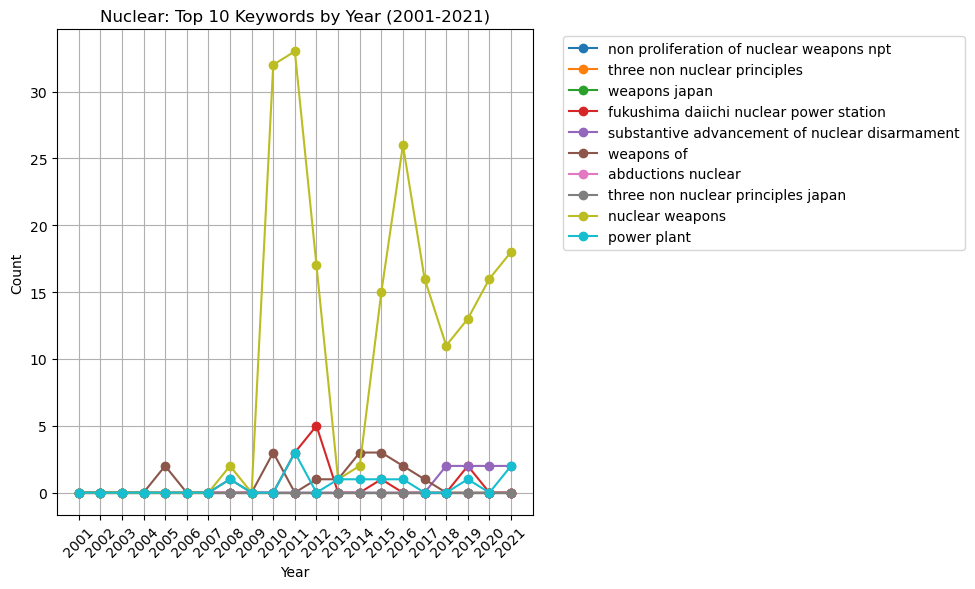

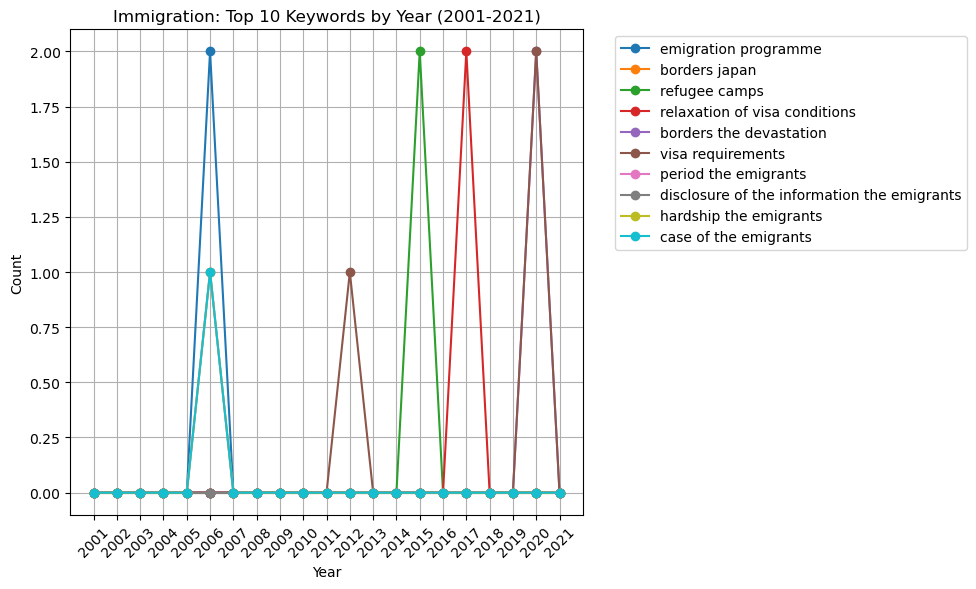

In [18]:
import matplotlib.pyplot as plt

for category in CATEGORY_KEYWORDS:
    phrases = top_category_keywords_df.loc[top_category_keywords_df["category"] == category, "phrase"]

    fig, ax = plt.subplots(figsize=(10, 6))
    for phrase in phrases:
        ax.plot(phrase_year_df.index, phrase_year_df[phrase], marker="o", label=phrase)

    ax.set_title(f"{category.capitalize()}: Top 10 Keywords by Year ({YEAR_START}-{YEAR_END})")
    ax.set_xlabel("Year")
    ax.set_ylabel("Count")
    ax.set_xticks(range(YEAR_START, YEAR_END + 1))
    ax.tick_params(axis="x", rotation=45)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.grid(True)
    plt.tight_layout()
    plt.show()


Now putting this under the categories: 

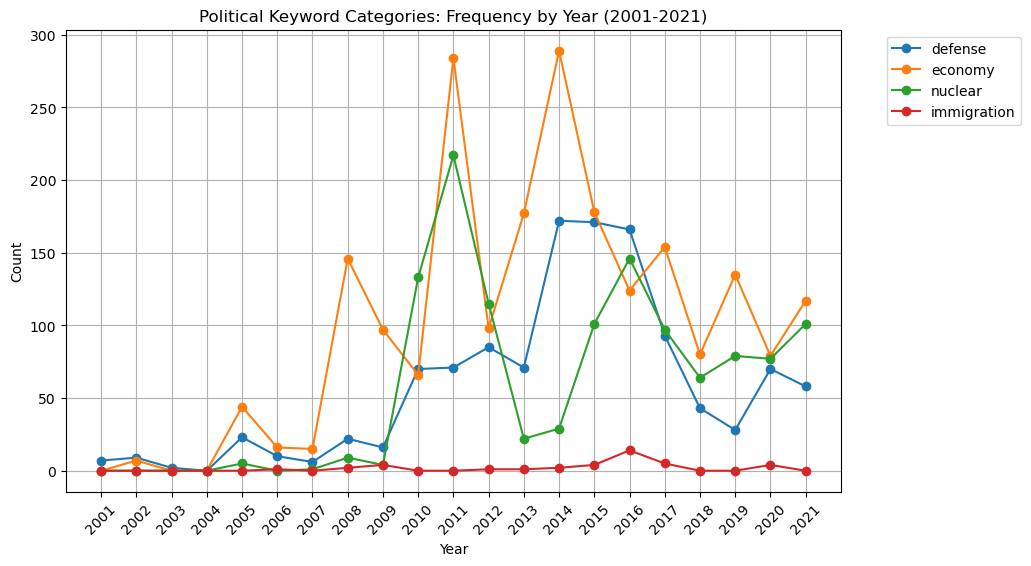

In [19]:
import re
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

category_patterns = {
    category: re.compile(
        r"\b(" + "|".join(re.escape(kw) for kw in keywords) + r")\b",
        re.IGNORECASE,
    )
    for category, keywords in CATEGORY_KEYWORDS.items()
}

category_year_counts = {category: defaultdict(int) for category in CATEGORY_KEYWORDS}

for date, row in speeches_range.iterrows():
    year = date.year
    text = str(row["text"])
    for category, pattern in category_patterns.items():
        count = len(pattern.findall(text))
        if count:
            category_year_counts[category][year] += count

category_year_df = pd.DataFrame(category_year_counts).reindex(range(YEAR_START, YEAR_END + 1)).fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
for category in CATEGORY_KEYWORDS:
    ax.plot(category_year_df.index, category_year_df[category], marker="o", label=category)

ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.set_title(f"Political Keyword Categories: Frequency by Year ({YEAR_START}-{YEAR_END})")
ax.set_xticks(range(YEAR_START, YEAR_END + 1))
ax.tick_params(axis="x", rotation=45)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True)
plt.show()


Now, matching the categories to news analysis categories and graphing: 

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

defense_keywords = ['defense', 'SDF', 'military', 'peace', 'article 9', 'threat']

economy_keywords = [
    'inflation', 'deflation', 'interest rate', 'exchange rate', 'GDP',
    'financial', 'tax', 'price level', 'unemployment',
]

nuclear_keywords = ['nuclear', 'Fukushima', 'reactor', 'energy', 'electricity']

immigration_keywords = ['immigration', 'immigrant', 'refugee', 'nationality', 'residency']

# Map each category to its keywords
categories = {
    "defense":     defense_keywords,
    "economy":     economy_keywords,
    "nuclear":     nuclear_keywords,
    "immigration": immigration_keywords,
}

def keyword_speech_count(keyword, df):
    return df['text'].str.contains(keyword, case=False, na=False).sum()

rows = []
for category, keywords in categories.items():
    for kw in keywords:
        count = keyword_speech_count(kw, speeches_range)
        rows.append({"category": category, "keyword": kw, "speech_count": count})

results_df = pd.DataFrame(rows).sort_values(["category", "speech_count"], ascending=[True, False])
results_df
rows = []
for category, keywords in categories.items():
    for kw in keywords:
        count = keyword_speech_count(kw, speeches_range)
        rows.append({"category": category, "keyword": kw, "speech_count": count})

results_df = pd.DataFrame(rows).sort_values(["category", "speech_count"], ascending=[True, False])
results_df["rank"] = results_df.groupby("category")["speech_count"].rank(method="first", ascending=False).astype(int)
results_df = results_df.set_index(["category", "rank"])
results_df



keyword  speech_count
category    rank                             
defense     1             peace           174
            2            threat            52
            3           defense            41
            4          military            29
            5               SDF            18
            6         article 9             0
economy     1         financial            42
            2               tax            28
            3               GDP            18
            4         deflation            14
            5      unemployment             2
            6         inflation             1
            7     interest rate             1
            8     exchange rate             1
            9       price level             0
immigration 1         residency            15
            2           refugee             8
            3       nationality             4
            4       immigration             1
            5         immigrant             0
nuclear     1           nuclear            99
            2            energy            72
            3         Fukushima            30
            4       electricity            19
            5           reactor             6

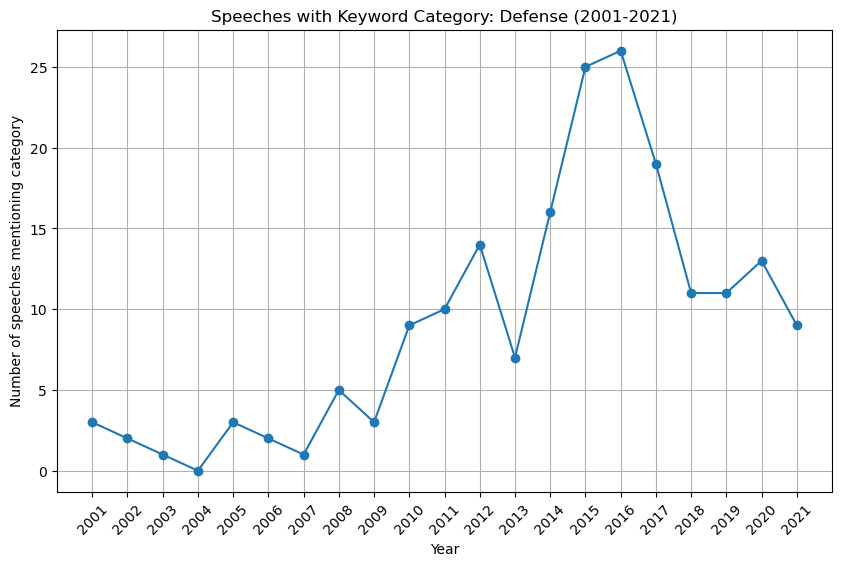

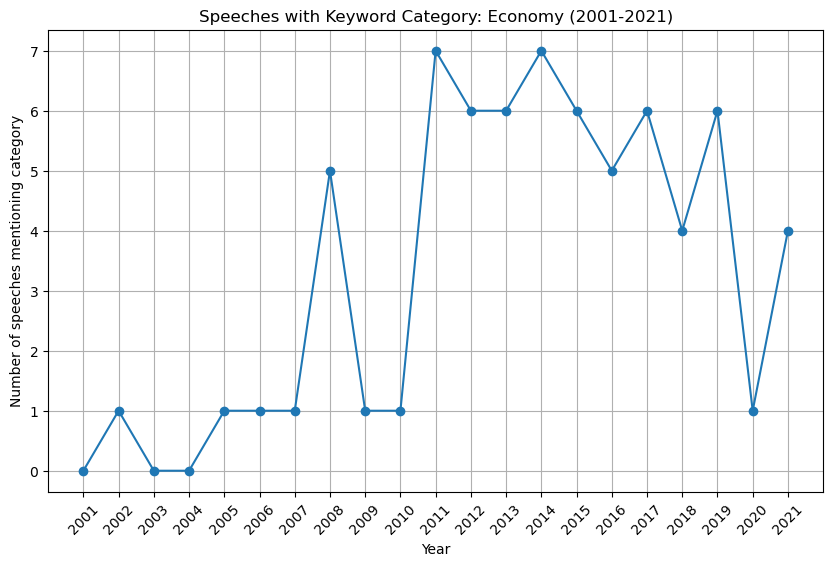

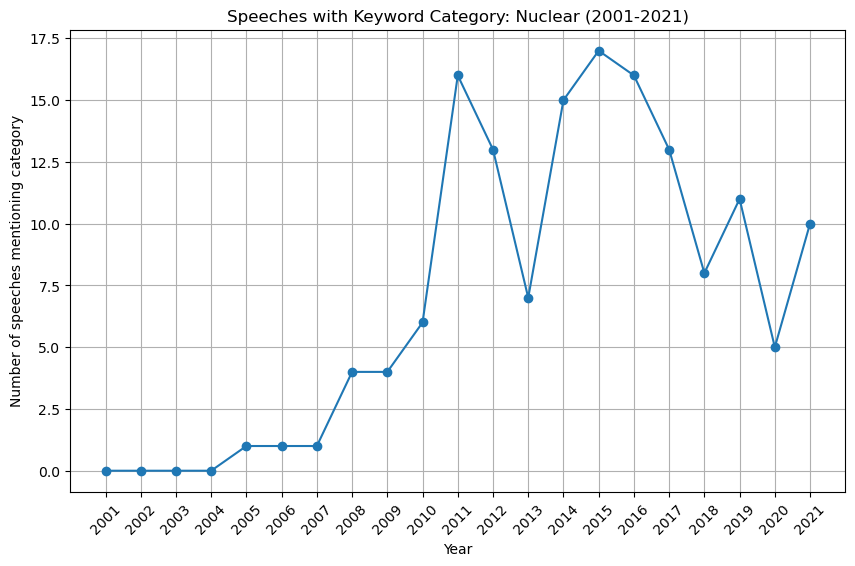

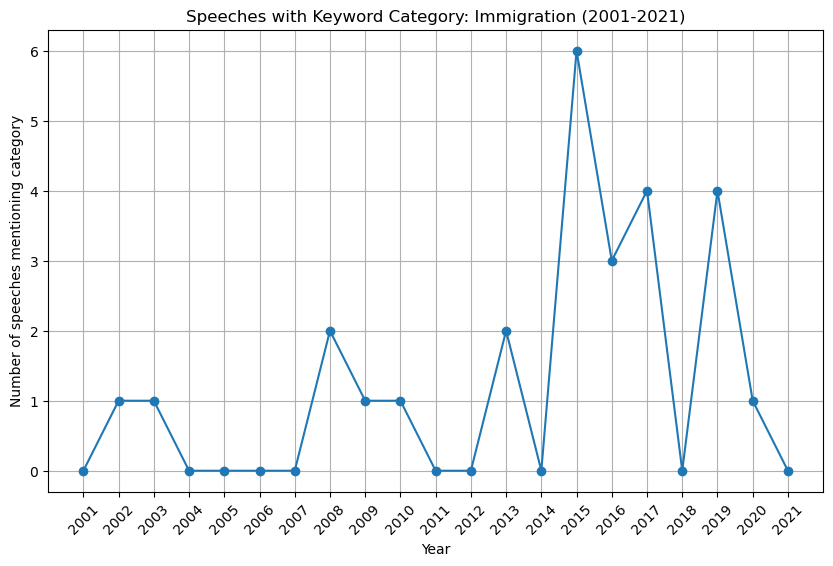

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

def category_graph(category_name, keywords, df, x_title, y_title, main_title):
    pattern = "|".join(keywords)
    speeches_keyword = df[df['text'].str.contains(pattern, case=False, na=False)]

    df_plot = speeches_keyword.resample('YE').size()
    df_plot = df_plot.reindex(pd.date_range(f"{YEAR_START}-01-01", f"{YEAR_END}-12-31", freq="YE"), fill_value=0)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(df_plot.index.year, df_plot.values, marker="o")
    ax.set_xlabel(x_title)
    ax.set_ylabel(y_title)
    ax.set_title(main_title)
    ax.set_xticks(range(YEAR_START, YEAR_END + 1))
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True)

    return fig

for category, keywords in categories.items():
    fig = category_graph(
        category_name=category,
        keywords=keywords,
        df=speeches_range,
        x_title="Year",
        y_title="Number of speeches mentioning category",
        main_title=f"Speeches with Keyword Category: {category.capitalize()} ({YEAR_START}-{YEAR_END})"
    )
    plt.show()


Number of speeches per month over time from 2001-2021

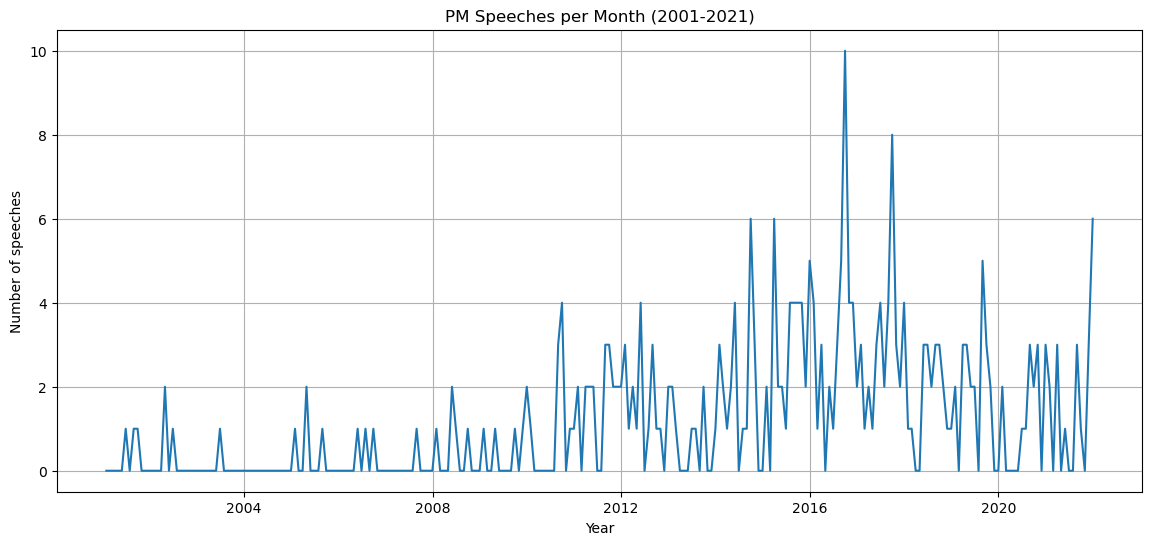

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

speeches_per_month = speeches_range.resample('ME').size()
speeches_per_month = speeches_per_month.reindex(
    pd.date_range(f"{YEAR_START}-01-01", f"{YEAR_END}-12-31", freq="ME"), fill_value=0
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(speeches_per_month.index, speeches_per_month.values)

ax.set_xlabel("Year")
ax.set_ylabel("Number of speeches")
ax.set_title(f"PM Speeches per Month ({YEAR_START}-{YEAR_END})")
ax.grid(True)
plt.show()


Word count for top 10 keywords 

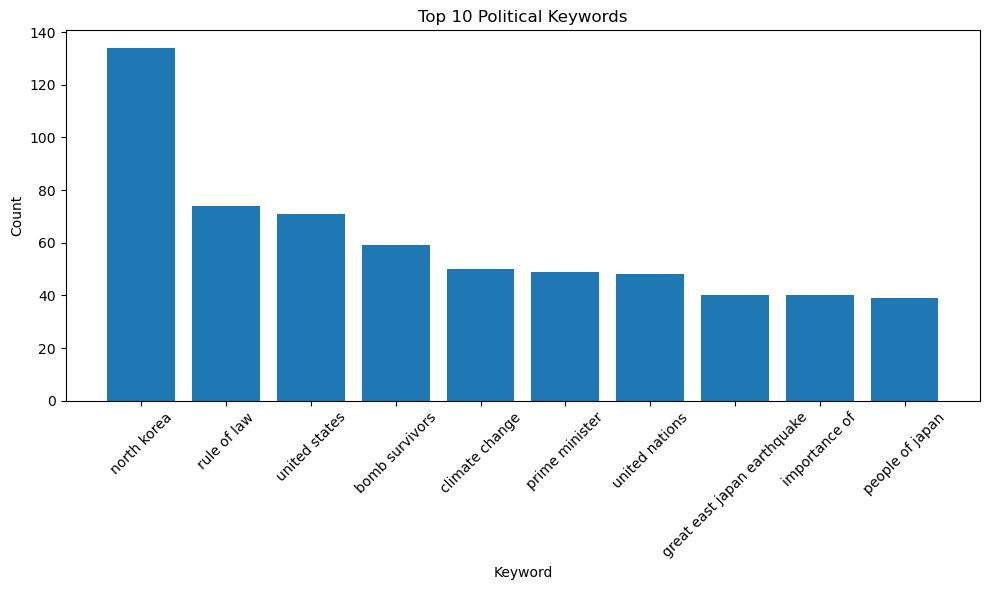

In [24]:
import matplotlib.pyplot as plt

top_10_df = top_political_phrases_df.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(top_10_df["phrase"], top_10_df["total_count"])

ax.set_xlabel("Keyword")
ax.set_ylabel("Count")
ax.set_title("Top 10 Political Keywords")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


In [29]:
import sys
print(sys.executable)

/opt/anaconda3/bin/python


In [30]:
import sys
!{sys.executable} -m pip install wordcloud

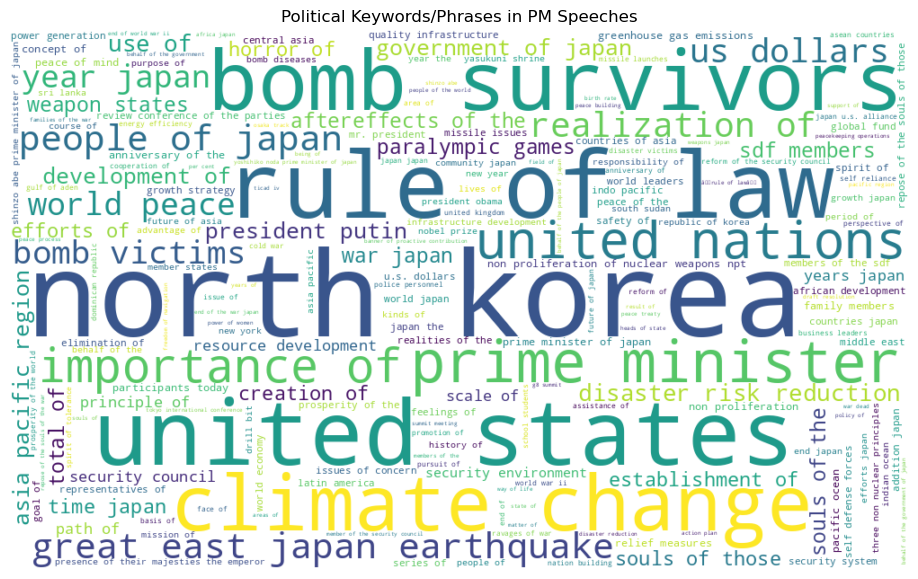

In [31]:
import re
from collections import Counter

import matplotlib.pyplot as plt
from wordcloud import WordCloud



STOPWORDS = {
    "the", "a", "an", "and", "or", "but", "of", "to", "in", "on", "for",
    "is", "are", "was", "were", "be", "been", "being", "this", "that",
    "it", "as", "with", "at", "by", "from", "we", "i", "you", "our", "us",
    "will", "have", "has", "had", "not", "their", "his", "her", "they",
    "japan", "japanese",
}

word_pattern = re.compile(r"\b[a-zA-Z]+\b")
common_word_counts = Counter()

for text in speeches_range["text"]:
    words = [w.lower() for w in word_pattern.findall(str(text)) if w.lower() not in STOPWORDS and len(w) > 2]
    common_word_counts.update(words)

# 2. Word cloud of political keywords/phrases (from the noun-phrase extraction)
political_wordcloud = WordCloud(width=1000, height=600, background_color="white").generate_from_frequencies(phrase_counts)

plt.figure(figsize=(12, 7))
plt.imshow(political_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Political Keywords/Phrases in PM Speeches")
plt.show()


Number of manifestos available to be read from pdf from 2001-2021 (correlating with news):

In [17]:
import os
import re

import pdfplumber

PDF_DIR = "../../data/raw/pdfs"
YEAR_START, YEAR_END = 2001, 2021

def file_year(filename):
    m = re.match(r"^\d+_(\d{4})\d{2}\.pdf$", filename)
    return int(m.group(1)) if m else None

def has_text(pdf_path):
    with pdfplumber.open(pdf_path, laparams={"detect_vertical": True}) as pdf:
        for page in pdf.pages:
            if (page.extract_text(x_tolerance=3, y_tolerance=3) or "").strip():
                return True
    return False

in_range, with_text, without_text = [], [], []

for filename in sorted(os.listdir(PDF_DIR)):
    if not filename.lower().endswith(".pdf"):
        continue
    year = file_year(filename)
    if year is None or not (YEAR_START <= year <= YEAR_END):
        continue
    in_range.append(filename)
    if has_text(os.path.join(PDF_DIR, filename)):
        with_text.append(filename)
    else:
        without_text.append(filename)

print(f"PDFs in {YEAR_START}-{YEAR_END}: {len(in_range)}")
print(f"  with extractable text: {len(with_text)}")
print(f"  scanned/image (no text): {len(without_text)}")
print(without_text)


PDFs in 2001-2021: 35
  with extractable text: 25
  scanned/image (no text): 10
['71320_200509.pdf', '71420_200311.pdf', '71430_201212.pdf', '71530_200311.pdf', '71530_200509.pdf', '71620_200311.pdf', '71620_200908.pdf', '71630_200509.pdf', '71630_201212.pdf', '71650_201212.pdf']


Most common 100 political phrases found in manifestos 

In [19]:
import pandas as pd
from collections import Counter, defaultdict

METADATA_CSV = "../../project/data/clean/Japan_sorted_manifestos.csv"
metadata_df = pd.read_csv(METADATA_CSV)[["manifesto_id", "partyname"]]

NOUN_POS = {"NOUN", "PROPN", "PRON"}
KANJI_NUMERALS = {"一", "二", "三", "四", "五", "六", "七", "八", "九", "十", "百", "千", "万", "億", "兆"}

def extract_text(pdf_path):
    with pdfplumber.open(pdf_path, laparams={"detect_vertical": True}) as pdf:
        pages = [page.extract_text(x_tolerance=3, y_tolerance=3) or "" for page in pdf.pages]
    return "\n".join(pages)

phrase_counts = Counter()
phrase_doc_ids = defaultdict(set)
phrase_parties = defaultdict(set)

for filename in with_text:  # the 2001-2021, text-bearing PDFs found in the previous cell
    manifesto_id = filename[:-4]
    party_row = metadata_df.loc[metadata_df["manifesto_id"] == manifesto_id, "partyname"]
    party = party_row.iloc[0] if not party_row.empty else "Unknown"

    text = extract_text(os.path.join(PDF_DIR, filename))
    for chunk in chunk_text(text):
        doc = nlp(chunk)
        tokens = [token for token in doc if not token.is_space and not token.is_punct]

        i = 0
        while i < len(tokens):
            phrase_tokens = []
            j = i
            while j < len(tokens) and (
                tokens[j].pos_ in NOUN_POS
                or (tokens[j].text == "の" and phrase_tokens)
                or (tokens[j].pos_ == "NUM" and tokens[j].text in KANJI_NUMERALS and phrase_tokens)
            ):
                phrase_tokens.append(tokens[j].text)
                j += 1

            if len(phrase_tokens) >= 2:
                phrase = "".join(phrase_tokens)
                phrase_counts[phrase] += 1
                phrase_doc_ids[phrase].add(manifesto_id)
                phrase_parties[phrase].add(party)

            i = j if j > i else i + 1

rows = [
    {
        "phrase": phrase,
        "total_count": count,
        "doc_freq": len(phrase_doc_ids[phrase]),
        "party_count": len(phrase_parties[phrase]),
        "parties": ", ".join(sorted(phrase_parties[phrase]))
    }
    for phrase, count in phrase_counts.items()
    if len(phrase_doc_ids[phrase]) >= 2  # drop one-off phrases that only appear in a single manifesto
]

political_concepts_df = pd.DataFrame(rows).sort_values("total_count", ascending=False).head(100).reset_index(drop=True)
political_concepts_df


,phrase,total_count,doc_freq,party_count,parties
0,日本共産党,132,4,2,"Japanese Communist Party, Unknown"
1,中小企業,84,16,3,"Japanese Communist Party, Social Democratic Pa..."
2,自治体,66,14,2,"Japanese Communist Party, Unknown"
3,消費税,58,15,2,"Japanese Communist Party, Unknown"
4,民主党,55,11,2,"Japanese Communist Party, Unknown"
...,...,...,...,...,...
95,政治主導,14,7,1,Unknown
96,地域の,13,7,1,Unknown
97,具体策,13,3,1,Unknown
98,実効性,13,7,1,Unknown


In [22]:
import time

from deep_translator import GoogleTranslator

translator = GoogleTranslator(source="ja", target="en")

def build_translation_dict(terms):
    translations = {}
    for term in terms:
        if term in translations:
            continue
        try:
            translations[term] = translator.translate(term)
        except Exception as e:
            translations[term] = None
            print(f"Failed to translate {term!r}: {e}")
        time.sleep(0.2)  # avoid tripping the free endpoint's rate limit
    return translations

translation_dict = build_translation_dict(political_concepts_df["phrase"])

political_concepts_df["english"] = political_concepts_df["phrase"].map(translation_dict)
political_concepts_df

political_concepts_df["english"] = political_concepts_df["phrase"].map(translation_dict)

cols = ["phrase", "english"] + [c for c in political_concepts_df.columns if c not in ("phrase", "english")]
political_concepts_df = political_concepts_df[cols]
political_concepts_df



,phrase,english,total_count,doc_freq,party_count,parties
0,日本共産党,Japanese Communist Party,132,4,2,"Japanese Communist Party, Unknown"
1,中小企業,small business,84,16,3,"Japanese Communist Party, Social Democratic Pa..."
2,自治体,local government,66,14,2,"Japanese Communist Party, Unknown"
3,消費税,consumption tax,58,15,2,"Japanese Communist Party, Unknown"
4,民主党,Democratic Party,55,11,2,"Japanese Communist Party, Unknown"
...,...,...,...,...,...,...
95,政治主導,politically driven,14,7,1,Unknown
96,地域の,regional,13,7,1,Unknown
97,具体策,concrete measures,13,3,1,Unknown
98,実効性,effectiveness,13,7,1,Unknown


Years will be sparse with gaps (manifestos only exist for election years — 2003, 2005, 2009, 2012, 2014 in your dataset, no 2017/2021 PDFs present), so the lines will visibly jump between data points rather than being smooth.

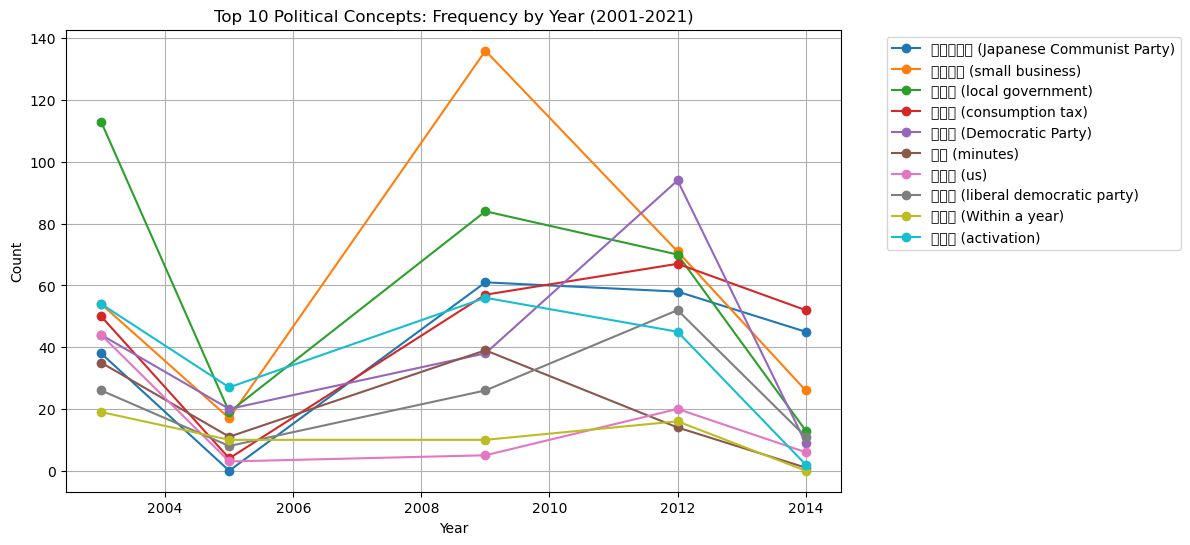

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
for phrase in top_phrases:
    label = f"{phrase} ({phrase_labels[phrase]})"
    ax.plot(phrase_year_df.index, phrase_year_df[phrase], marker="o", label=label)

ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.set_title("Top 10 Political Concepts: Frequency by Year (2001-2021)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True)
plt.show()

the project's only party-name metadata (Japan_sorted_manifestos.csv) covers just 9 manifestos (2014-12 and 2017-10), so only 4 of the ~15 party codes in your 2001-2021 PDFs map to a real name (Japanese Communist Party, Social Democratic Party, New Clean Government Party, Liberal Democratic Party) — party codes are stable across elections so this mapping still applies to your older PDFs, but the rest will show as their raw numeric ID since there's no name on file. Let me know if you have a fuller party-code lookup; for now the chart falls back to the ID.

In [25]:
import math
import os
import re
import time
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import pandas as pd
import pdfplumber
import spacy
from deep_translator import GoogleTranslator

PDF_DIR = "../../data/raw/pdfs"
METADATA_CSV = "../../project/data/clean/Japan_sorted_manifestos.csv"
YEAR_START, YEAR_END = 2001, 2021
TOP_N = 10
MIN_DOC_FREQ = 2
CHUNK_SIZE = 8000

NOUN_POS = {"NOUN", "PROPN", "PRON"}
KANJI_NUMERALS = {"一", "二", "三", "四", "五", "六", "七", "八", "九", "十", "百", "千", "万", "億", "兆"}

nlp = spacy.load("ja_core_news_sm")
translator = GoogleTranslator(source="ja", target="en")

# party_id (stable across elections) -> party name, built from whatever metadata is on file
metadata_df = pd.read_csv(METADATA_CSV)
metadata_df["party_id"] = metadata_df["manifesto_id"].str.split("_").str[0]
party_id_to_name = dict(zip(metadata_df["party_id"], metadata_df["partyname"]))

def file_year(filename):
    m = re.match(r"^\d+_(\d{4})\d{2}\.pdf$", filename)
    return int(m.group(1)) if m else None

def file_party_id(filename):
    return filename.split("_")[0]

def extract_text(pdf_path):
    with pdfplumber.open(pdf_path, laparams={"detect_vertical": True}) as pdf:
        pages = [page.extract_text(x_tolerance=3, y_tolerance=3) or "" for page in pdf.pages]
    return "\n".join(pages)

def chunk_text(text, max_chars=CHUNK_SIZE):
    return [text[i:i + max_chars] for i in range(0, len(text), max_chars)]

# --- Extract phrases, tracking counts per (party, year) as well as overall ---
phrase_counts = Counter()
phrase_doc_ids = defaultdict(set)
party_year_phrase_counts = defaultdict(lambda: defaultdict(Counter))  # party -> year -> Counter(phrase)

for filename in sorted(os.listdir(PDF_DIR)):
    if not filename.lower().endswith(".pdf"):
        continue
    year = file_year(filename)
    if year is None or not (YEAR_START <= year <= YEAR_END):
        continue

    text = extract_text(os.path.join(PDF_DIR, filename))
    if not text.strip():
        continue  # scanned/image PDF, no text layer

    manifesto_id = filename[:-4]
    party_id = file_party_id(filename)
    party = party_id_to_name.get(party_id, party_id)

    for chunk in chunk_text(text):
        doc = nlp(chunk)
        tokens = [token for token in doc if not token.is_space and not token.is_punct]

        i = 0
        while i < len(tokens):
            phrase_tokens = []
            j = i
            while j < len(tokens) and (
                tokens[j].pos_ in NOUN_POS
                or (tokens[j].text == "の" and phrase_tokens)
                or (tokens[j].pos_ == "NUM" and tokens[j].text in KANJI_NUMERALS and phrase_tokens)
            ):
                phrase_tokens.append(tokens[j].text)
                j += 1

            if len(phrase_tokens) >= 2:
                phrase = "".join(phrase_tokens)
                phrase_counts[phrase] += 1
                phrase_doc_ids[phrase].add(manifesto_id)
                party_year_phrase_counts[party][year][phrase] += 1

            i = j if j > i else i + 1


generated keywords but not political phrases: 

In [20]:
# pip install deep-translator   (already installed in your anaconda env)
import time

from deep_translator import GoogleTranslator

translator = GoogleTranslator(source="ja", target="en")

def build_translation_dict(terms):
    translations = {}
    for term in terms:
        if term in translations:
            continue
        try:
            translations[term] = translator.translate(term)
        except Exception as e:
            translations[term] = None
            print(f"Failed to translate {term!r}: {e}")
        time.sleep(0.2)  # be polite to the free endpoint, avoid rate-limit errors
    return translations

translation_dict = build_translation_dict(top_100["keyword"])

top_100["english"] = top_100["keyword"].map(translation_dict)
top_100


,keyword,count,english
0,cid,13095,cid
1,ため,1526,Because
2,制度,1377,system
3,地域,1258,region
4,こと,1223,thing
...,...,...,...
95,原則,229,principle
96,向上,228,improvement
97,住宅,227,housing
98,新た,227,new


In [10]:
import os
import pandas as pd
import pdfplumber

PDF_DIR = "../../data/raw/pdfs"  # repo-root data/raw/pdfs, relative to project/notebooks/

def extract_words(pdf_path):
    """Extract every word from a PDF, including vertical (tategaki) Japanese text."""
    rows = []
    with pdfplumber.open(pdf_path, laparams={"detect_vertical": True}) as pdf:
        for page_num, page in enumerate(pdf.pages, start=1):
            words = page.extract_words(x_tolerance=3, y_tolerance=3, extra_attrs=["upright"])
            for w in words:
                rows.append({
                    "filename": os.path.basename(pdf_path),
                    "page": page_num,
                    "word": w["text"],
                    "upright": w["upright"],  # False = rotated glyph, True = drawn upright (most tategaki Japanese)
                    "x0": w["x0"],
                    "top": w["top"],
                })
    return rows

all_words = []
for filename in sorted(os.listdir(PDF_DIR)):
    if not filename.lower().endswith(".pdf"):
        continue
    path = os.path.join(PDF_DIR, filename)
    try:
        rows = extract_words(path)
        if not rows:
            print(f"No words extracted from {filename} (likely a scanned/image PDF, needs OCR)")
        all_words.extend(rows)
    except Exception as e:
        print(f"Failed on {filename}: {e}")

words_df = pd.DataFrame(all_words)
words_df.head()


No words extracted from 71220_196011.pdf (likely a scanned/image PDF, needs OCR)
No words extracted from 71220_196311.pdf (likely a scanned/image PDF, needs OCR)
No words extracted from 71220_196912.pdf (likely a scanned/image PDF, needs OCR)
No words extracted from 71220_197212.pdf (likely a scanned/image PDF, needs OCR)
No words extracted from 71220_197612.pdf (likely a scanned/image PDF, needs OCR)
No words extracted from 71220_197910.pdf (likely a scanned/image PDF, needs OCR)
No words extracted from 71220_198006.pdf (likely a scanned/image PDF, needs OCR)
No words extracted from 71320_196011.pdf (likely a scanned/image PDF, needs OCR)
No words extracted from 71320_196311.pdf (likely a scanned/image PDF, needs OCR)
No words extracted from 71320_196912.pdf (likely a scanned/image PDF, needs OCR)
No words extracted from 71320_197212.pdf (likely a scanned/image PDF, needs OCR)
No words extracted from 71320_197612.pdf (likely a scanned/image PDF, needs OCR)
No words extracted from 7132

KeyboardInterrupt: 

In [6]:
import os
import pandas as pd
import pdfplumber

PDF_DIR = "../../data/raw/pdfs"

In [9]:
import os
import re
from collections import Counter

import pandas as pd
import pdfplumber
import spacy

PDF_DIR = "../../data/raw/pdfs"
YEAR_START, YEAR_END = 2001, 2021
TARGET_POS = {"NOUN", "PROPN", "ADJ"}
CHUNK_SIZE = 8000  # characters per nlp() call, safely under Sudachi's ~49KB byte limit

nlp = spacy.load("ja_core_news_sm")

def file_year(filename):
    m = re.match(r"^\d+_(\d{4})\d{2}\.pdf$", filename)
    return int(m.group(1)) if m else None

def extract_text(pdf_path):
    with pdfplumber.open(pdf_path, laparams={"detect_vertical": True}) as pdf:
        pages = [page.extract_text(x_tolerance=3, y_tolerance=3) or "" for page in pdf.pages]
    return "\n".join(pages)

def chunk_text(text, max_chars=CHUNK_SIZE):
    return [text[i:i + max_chars] for i in range(0, len(text), max_chars)]

keyword_counter = Counter()
used_files, skipped_image_files, skipped_year_files = [], [], []

for filename in sorted(os.listdir(PDF_DIR)):
    if not filename.lower().endswith(".pdf"):
        continue
    year = file_year(filename)
    if year is None or not (YEAR_START <= year <= YEAR_END):
        skipped_year_files.append(filename)
        continue

    text = extract_text(os.path.join(PDF_DIR, filename))
    if not text.strip():
        skipped_image_files.append(filename)  # scanned/image PDF, no text layer
        continue

    used_files.append(filename)
    for chunk in chunk_text(text):
        doc = nlp(chunk)
        for token in doc:
            if token.pos_ in TARGET_POS and not token.is_punct and not token.is_space and len(token.text.strip()) > 1:
                keyword_counter[token.lemma_] += 1

top_100 = pd.DataFrame(keyword_counter.most_common(100), columns=["keyword", "count"])

print(f"Used {len(used_files)} text-based PDFs ({YEAR_START}-{YEAR_END})")
print(f"Skipped {len(skipped_image_files)} scanned/image PDFs in range: {skipped_image_files}")
top_100


Used 25 text-based PDFs (2001-2021)
Skipped 10 scanned/image PDFs in range: ['71320_200509.pdf', '71420_200311.pdf', '71430_201212.pdf', '71530_200311.pdf', '71530_200509.pdf', '71620_200311.pdf', '71620_200908.pdf', '71630_200509.pdf', '71630_201212.pdf', '71650_201212.pdf']


,keyword,count
0,cid,13095
1,ため,1526
2,制度,1377
3,地域,1258
4,こと,1223
...,...,...
95,原則,229
96,向上,228
97,住宅,227
98,新た,227


In [13]:
import os

import pandas as pd
import pdfplumber

PDF_DIR = "../../data/raw/pdfs"
METADATA_CSV = "../../project/data/clean/Japan_sorted_manifestos.csv"
OUTPUT_CSV = "../../project/data/clean/Japan_manifestos_from_pdfs.csv"

def extract_text(pdf_path):
    """detect_vertical=True makes pdfplumber recognize both vertical (tategaki)
    columns and ordinary horizontal lines on the same page, so text isn't lost
    either way -- it's a single pass, not two separate horizontal/vertical runs."""
    with pdfplumber.open(pdf_path, laparams={"detect_vertical": True}) as pdf:
        pages = [page.extract_text(x_tolerance=3, y_tolerance=3) or "" for page in pdf.pages]
    return "\n".join(pages)

rows = []
for filename in sorted(os.listdir(PDF_DIR)):
    if not filename.lower().endswith(".pdf"):
        continue
    manifesto_id = filename[:-4]
    text = extract_text(os.path.join(PDF_DIR, filename))
    if not text.strip():
        print(f"Skipping {filename}: no extractable text (likely a scanned image)")
        continue
    rows.append({"manifesto_id": manifesto_id, "text": text})

pdf_text_df = pd.DataFrame(rows)

# Reuse the partyname/date metadata already curated for the API-sourced csv
metadata_df = pd.read_csv(METADATA_CSV)[["manifesto_id", "partyname", "date"]]
manifesto_pdf_df = pdf_text_df.merge(metadata_df, on="manifesto_id", how="left")

manifesto_pdf_df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(manifesto_pdf_df)} PDF-sourced manifestos to {OUTPUT_CSV}")
manifesto_pdf_df.head()


Skipping 71220_196011.pdf: no extractable text (likely a scanned image)
Skipping 71220_196311.pdf: no extractable text (likely a scanned image)
Skipping 71220_196912.pdf: no extractable text (likely a scanned image)
Skipping 71220_197212.pdf: no extractable text (likely a scanned image)
Skipping 71220_197612.pdf: no extractable text (likely a scanned image)
Skipping 71220_197910.pdf: no extractable text (likely a scanned image)
Skipping 71220_198006.pdf: no extractable text (likely a scanned image)
Skipping 71320_196011.pdf: no extractable text (likely a scanned image)
Skipping 71320_196311.pdf: no extractable text (likely a scanned image)
Skipping 71320_196912.pdf: no extractable text (likely a scanned image)
Skipping 71320_197212.pdf: no extractable text (likely a scanned image)
Skipping 71320_197612.pdf: no extractable text (likely a scanned image)
Skipping 71320_197910.pdf: no extractable text (likely a scanned image)
Skipping 71320_198006.pdf: no extractable text (likely a scanned

,manifesto_id,text,partyname,date
0,71110_201212,「\n卒\n原\n発\n」\nも\n「\n脱\n増\n税\n」\nも\n［ 未 来 へ の ...,NaN,NaN
1,71111_201412,生\n活\n者\n本\n位\nの\n国\nへ\n。\n生\n活\nの\n党\n● ● ●\n...,NaN,NaN
2,71220_200311,（前ページからつづく）\n自民党政治を\n当面の重点政策 イラク派兵と先制攻撃戦略への\n1...,NaN,NaN
3,71220_200509,(cid:11172)(cid:7856)(cid:3496)(cid:6707)(cid:...,NaN,NaN
4,71220_200908,「国民が主人公」の\n新しい日本を\n日本共産党の\n総選挙政策\n2009年7月28日\n...,NaN,NaN


In [15]:
import spacy
from collections import Counter, defaultdict

nlp = spacy.load("ja_core_news_sm")

def chunk_text(text, max_bytes=40000):
    encoded = text.encode("utf-8")
    chunks = []
    while encoded:
        chunk = encoded[:max_bytes]
        chunk = chunk.decode("utf-8", errors="ignore")
        chunks.append(chunk)
        encoded = encoded[len(chunk.encode("utf-8")):]
    return chunks

excluded_words = {"の", "に", "は", "を", "た", "が", "で", "て", "と", "し", "ます", "する", "な", "や", "も", "へ"}


In [16]:
def get_party_word_counts(csv_path, start_year=2001, end_year=2021):
    df = pd.read_csv(csv_path)
    df["year"] = pd.to_datetime(df["date"]).dt.year
    df = df[(df["year"] >= start_year) & (df["year"] <= end_year)]

    party_counts = {}
    for party, group in df.groupby("partyname"):
        tokens = []
        for text in group["text"]:
            for chunk in chunk_text(str(text)):
                doc = nlp(chunk)
                tokens.extend([
                    token.text for token in doc
                    if not token.is_space
                    and not token.is_punct
                    and token.text not in excluded_words
                ])
        party_counts[party] = Counter(tokens)

    return party_counts

party_counts = get_party_word_counts(OUTPUT_CSV, start_year=2001, end_year=2021)

party_word_sets = {party: set(counter) for party, counter in party_counts.items()}
common_to_all = set.intersection(*party_word_sets.values())

overlap_df = pd.DataFrame([
    {
        "word": word,
        **{party: party_counts[party][word] for party in party_counts},
        "total": sum(party_counts[party][word] for party in party_counts)
    }
    for word in common_to_all
]).sort_values(by="total", ascending=False).reset_index(drop=True)

overlap_df


,word,Japanese Communist Party,Social Democratic Party,total
0,的,59,71,130
1,税,97,32,129
2,者,53,68,121
3,など,65,54,119
4,日本,105,2,107
...,...,...,...,...
768,限,1,1,2
769,租税,1,1,2
770,仮設,1,1,2
771,就職,1,1,2
